# GP on a 2D Grid with Kronecker Structure

When data lives on a regular grid, the kernel matrix factorizes as
$K = K_x \otimes K_y$. This enables GP inference on grids with
thousands of points that would be intractable with a dense kernel.

This example fits a 2D GP to noisy observations on a grid using
Kronecker structure for solve, logdet, and prediction.

In [1]:
from __future__ import annotations

import jax
import jax.numpy as jnp
import lineax as lx
import matplotlib.pyplot as plt

import gaussx


jax.config.update("jax_enable_x64", True)

## Generate 2D grid data

In [2]:
# Grid
nx, ny = 15, 15
N = nx * ny
x = jnp.linspace(0, 4, nx)
y = jnp.linspace(0, 4, ny)
xx, yy = jnp.meshgrid(x, y, indexing="ij")


# True function: a smooth 2D surface
def f_true(x, y):
    return jnp.sin(x) * jnp.cos(1.5 * y)


z_true = f_true(xx, yy)

# Noisy observations
noise_std = 0.15
key = jax.random.PRNGKey(7)
z_obs = z_true + noise_std * jax.random.normal(key, z_true.shape)

print(f"Grid: {nx}x{ny} = {N} points")

Grid: 15x15 = 225 points


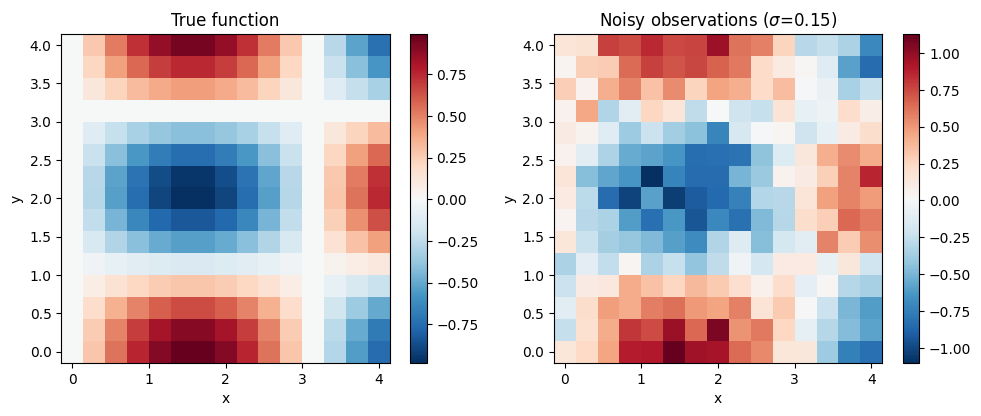

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
im0 = axes[0].pcolormesh(xx, yy, z_true, cmap="RdBu_r", shading="auto")
axes[0].set_title("True function")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].pcolormesh(xx, yy, z_obs, cmap="RdBu_r", shading="auto")
axes[1].set_title(f"Noisy observations ($\\sigma$={noise_std})")
plt.colorbar(im1, ax=axes[1])

for ax in axes:
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal")

plt.tight_layout()
plt.show()

## Build Kronecker kernel

Separable RBF: $k((x_1,y_1), (x_2,y_2)) = k_x(x_1,x_2) \cdot k_y(y_1,y_2)$

In [4]:
def rbf_1d(coords, lengthscale, variance):
    sq_dist = (coords[:, None] - coords[None, :]) ** 2
    return variance * jnp.exp(-0.5 * sq_dist / lengthscale**2)


ls_x, ls_y = 1.0, 1.0
var_x, var_y = 1.0, 1.0
noise_var = noise_std**2

Kx = rbf_1d(x, ls_x, var_x)
Ky = rbf_1d(y, ls_y, var_y)

Kx_op = lx.MatrixLinearOperator(Kx, lx.positive_semidefinite_tag)
Ky_op = lx.MatrixLinearOperator(Ky, lx.positive_semidefinite_tag)

# Full kernel: Kx kron Ky + noise * I
K_kron = gaussx.Kronecker(Kx_op, Ky_op)

print(f"Kronecker kernel: {K_kron.in_size()}x{K_kron.out_size()}")
print(f"Storage: {nx}x{nx} + {ny}x{ny} = {nx**2 + ny**2}")
print(f"Dense would be: {N}x{N} = {N**2:,}")

Kronecker kernel: 225x225
Storage: 15x15 + 15x15 = 450
Dense would be: 225x225 = 50,625


## Add noise and solve

We need $(K_x \otimes K_y + \sigma^2 I) \alpha = z_\mathrm{obs}$.
For now we add noise to the dense matrix; a full implementation
would keep this structured.

In [5]:
K_noisy = K_kron.as_matrix() + noise_var * jnp.eye(N)
op = lx.MatrixLinearOperator(K_noisy, lx.positive_semidefinite_tag)

# Flatten observations for solve
z_vec = z_obs.ravel()
alpha = gaussx.solve(op, z_vec)

# Posterior mean on the same grid
z_pred = (K_kron.as_matrix() @ alpha).reshape(nx, ny)

print(f"Solve residual: {jnp.max(jnp.abs(op.mv(alpha) - z_vec)):.2e}")

Solve residual: 3.15e-14


## Log-marginal likelihood

In [6]:
def lml(z, op):
    alpha = gaussx.solve(op, z)
    n = len(z)
    ld = gaussx.logdet(op)
    return -0.5 * jnp.dot(z, alpha) - 0.5 * ld - 0.5 * n * jnp.log(2 * jnp.pi)


print(f"Log-marginal likelihood: {lml(z_vec, op):.2f}")

Log-marginal likelihood: 55.04


## Visualize results

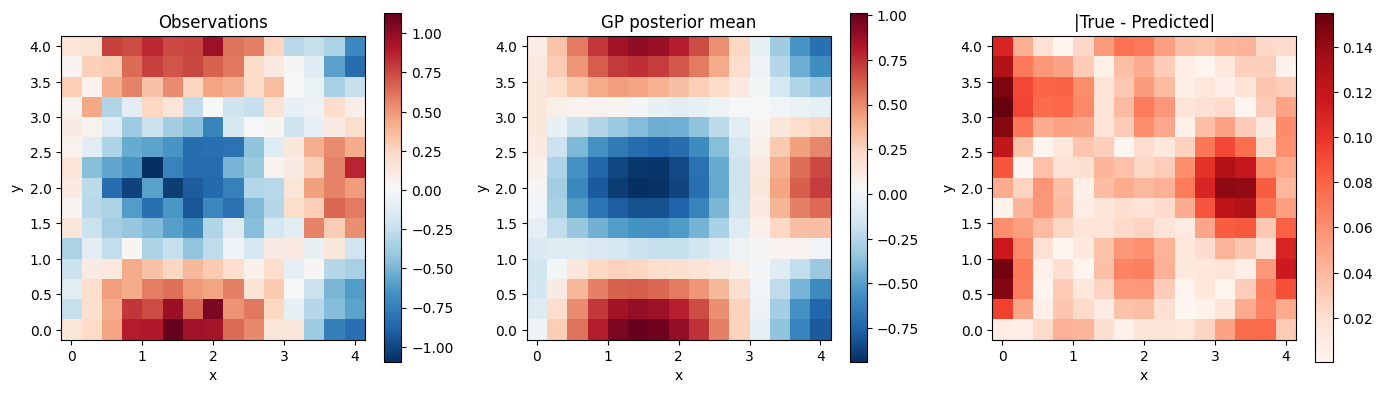

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

im0 = axes[0].pcolormesh(xx, yy, z_obs, cmap="RdBu_r", shading="auto")
axes[0].set_title("Observations")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].pcolormesh(xx, yy, z_pred, cmap="RdBu_r", shading="auto")
axes[1].set_title("GP posterior mean")
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].pcolormesh(xx, yy, jnp.abs(z_true - z_pred), cmap="Reds", shading="auto")
axes[2].set_title("|True - Predicted|")
plt.colorbar(im2, ax=axes[2])

for ax in axes:
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal")

plt.tight_layout()
plt.show()

## Kronecker-only operations

Even though we fell back to dense for the noisy solve,
the Kronecker structure enables cheap operations on the
kernel itself.

In [8]:
print("logdet(Kx kron Ky):")
print(f"  Structured: {gaussx.logdet(K_kron):.4f}")
print(f"  Dense:      {jnp.linalg.slogdet(K_kron.as_matrix())[1]:.4f}")

print("\ntrace(Kx kron Ky):")
print(f"  Structured: {gaussx.trace(K_kron):.4f}")
print(f"  Dense:      {jnp.trace(K_kron.as_matrix()):.4f}")

L_kron = gaussx.cholesky(K_kron)
print(f"\ncholesky type: {type(L_kron).__name__}")

logdet(Kx kron Ky):


  Structured: -4064.3464
  Dense:      -3904.5906

trace(Kx kron Ky):
  Structured: 225.0000


  Dense:      225.0000

cholesky type: Kronecker
